# Dataset exploration

This notebook loads the project's dataset files and produces summary statistics and visualizations: year and citation distributions, graph connectivity, and candidate-pair breakdowns.


In [3]:
import os
from pathlib import Path
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

sns.set(style="whitegrid")

ROOT = Path(".")
DATA_DIR = ROOT / "data"
OUT_DIR = ROOT / "outputs" / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Data dir:", DATA_DIR.resolve())


Data dir: C:\Users\elech\OneDrive\Documents\172\semantic-recommendation\data


In [4]:
# Load data files

def read_jsonl(path):
    try:
        return pd.read_json(path, lines=True)
    except Exception:
        return pd.DataFrame()

papers_path = DATA_DIR / "cleaned_papers.jsonl"
edges_path = DATA_DIR / "graph_edges.csv"
pairs_path = DATA_DIR / "candidate_pairs.csv"

papers = read_jsonl(papers_path) if papers_path.exists() else pd.DataFrame()
edges = pd.read_csv(edges_path) if edges_path.exists() else pd.DataFrame()
pairs = pd.read_csv(pairs_path) if pairs_path.exists() else pd.DataFrame()

print("papers:", getattr(papers, 'shape', None))
print("edges:", getattr(edges, 'shape', None))
print("pairs:", getattr(pairs, 'shape', None))

# preview
papers.head()


papers: (298296, 22)
edges: (218964, 7)
pairs: (151, 13)


,paperId,corpusId,doi,url,title,abstract,year,venue,publicationVenue,publicationDate,...,referenceCount,influentialCitationCount,isOpenAccess,openAccessPdfUrl,fieldsOfStudy,s2FieldsOfStudy,publicationTypes,authors,low_connectivity,text_for_retrieval
0,02b2e9ecccdbee1b570039fb16a9cbc000fbceca,263264421,10.1002/pro.4792,https://www.semanticscholar.org/paper/02b2e9ec...,UCSF ChimeraX: Tools for structure building an...,Advances in computational tools for atomic mod...,2023.0,Protein Science,Protein Science,2023-09-29,...,45,356,True,https://onlinelibrary.wiley.com/doi/pdfdirect/...,"[""Medicine""]","[{""category"": ""Medicine"", ""source"": ""external""...","[""JournalArticle""]",Elaine C. Meng; Thomas D. Goddard; E. Petterse...,False,UCSF ChimeraX: Tools for structure building an...
1,1b0f498d3d314d69850046574272404c52539302,269184445,10.1136/bmj-2023-078378,https://www.semanticscholar.org/paper/1b0f498d...,TRIPOD+AI statement: updated guidance for repo...,The TRIPOD (Transparent Reporting of a multiva...,2024.0,British medical journal,British medical journal,2024-04-16,...,101,52,True,https://www.bmj.com/content/bmj/385/bmj-2023-0...,"[""Medicine""]","[{""category"": ""Medicine"", ""source"": ""external""...","[""JournalArticle""]",Gary S. Collins; K. Moons; P. Dhiman; R. Riley...,False,TRIPOD+AI statement: updated guidance for repo...
2,bf8491bef353df126e2306ad2fe4b898697b906a,256662612,10.18653/v1/2023.ijcnlp-main.45,https://www.semanticscholar.org/paper/bf8491be...,"A Multitask, Multilingual, Multimodal Evaluati...",This paper proposes a framework for quantitati...,2023.0,International Joint Conference on Natural Lang...,International Joint Conference on Natural Lang...,2023-02-08,...,151,64,True,https://aclanthology.org/2023.ijcnlp-main.45.pdf,"[""Computer Science""]","[{""category"": ""Computer Science"", ""source"": ""e...","[""JournalArticle"", ""Conference""]",Yejin Bang; Samuel Cahyawijaya; Nayeon Lee; We...,False,"A Multitask, Multilingual, Multimodal Evaluati..."
3,2258e69186c4ab39cbf4868746bba651c086f1d9,269559058,10.38124/ijisrt/ijisrt24apr872,https://www.semanticscholar.org/paper/2258e691...,Enhancements in Immediate Speech Emotion Detec...,Speech is essential to human communication for...,2024.0,International Journal of Innovative Science an...,International Journal of Innovative Science an...,2024-05-02,...,34,0,False,,null,"[{""category"": ""Computer Science"", ""source"": ""s...","[""JournalArticle""]",Zewar Shah; Shan Zhiyong; Adnan,False,Enhancements in Immediate Speech Emotion Detec...
4,682f367e0e2ee66d7ff56a667f6d7e152807941c,274127839,10.1093/nar/gkae1010,https://www.semanticscholar.org/paper/682f367e...,UniProt: the Universal Protein Knowledgebase i...,Abstract The aim of the UniProt Knowledgebase ...,2024.0,Nucleic Acids Research,Nucleic Acids Research,2024-11-18,...,32,73,False,,"[""Medicine""]","[{""category"": ""Medicine"", ""source"": ""external""...","[""JournalArticle"", ""Review""]",Alex Maria-Jesus Sandra Michele Aduragbemi Sha...,False,UniProt: the Universal Protein Knowledgebase i...


In [5]:
# Inspect columns and basic stats

for df, name in [(papers, 'papers'), (edges, 'edges'), (pairs, 'pairs')]:
    print(f"--- {name} ---")
    if df is None or df.empty:
        print("(missing or empty)")
        continue
    print("rows:", len(df))
    print(df.dtypes.value_counts())
    print(df.columns.tolist())
    print(df.head(2).to_dict(orient='records'))
    print()


--- papers ---
rows: 298296
str        15
int64       4
bool        2
float64     1
Name: count, dtype: int64
['paperId', 'corpusId', 'doi', 'url', 'title', 'abstract', 'year', 'venue', 'publicationVenue', 'publicationDate', 'journal', 'citationCount', 'referenceCount', 'influentialCitationCount', 'isOpenAccess', 'openAccessPdfUrl', 'fieldsOfStudy', 's2FieldsOfStudy', 'publicationTypes', 'authors', 'low_connectivity', 'text_for_retrieval']
[{'paperId': '02b2e9ecccdbee1b570039fb16a9cbc000fbceca', 'corpusId': 263264421, 'doi': '10.1002/pro.4792', 'url': 'https://www.semanticscholar.org/paper/02b2e9ecccdbee1b570039fb16a9cbc000fbceca', 'title': 'UCSF ChimeraX: Tools for structure building and analysis', 'abstract': 'Advances in computational tools for atomic model building are leading to accurate models of large molecular assemblies seen in electron microscopy, often at challenging resolutions of 3–4\u2009Å. We describe new methods in the UCSF ChimeraX molecular modeling package that take 

In [6]:
# Clean / prepare

# Ensure numeric columns
if not papers.empty:
    if 'year' in papers.columns:
        papers['year'] = pd.to_numeric(papers['year'], errors='coerce')
    for c in ['citationCount', 'referenceCount']:
        if c in papers.columns:
            papers[c] = pd.to_numeric(papers[c], errors='coerce').fillna(0).astype(int)

# For edges and pairs
if not edges.empty:
    for c in ['hop']:
        if c in edges.columns:
            edges[c] = pd.to_numeric(edges[c], errors='coerce').fillna(1).astype(int)

if not pairs.empty:
    for c in ['hop','candidate_citationCount','candidate_year']:
        if c in pairs.columns:
            pairs[c] = pd.to_numeric(pairs[c], errors='coerce')

print('cleaning done')


cleaning done


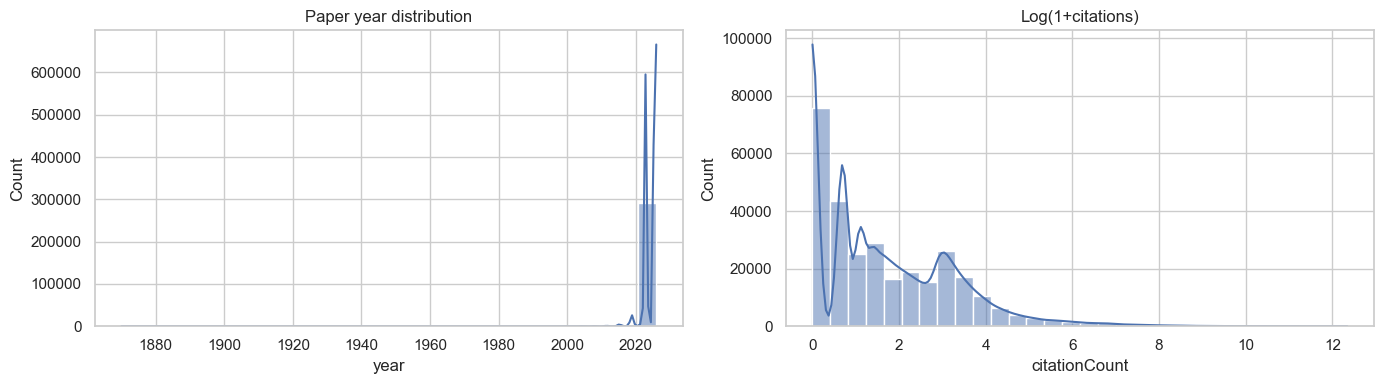

In [7]:
# Numerical distributions

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

if not papers.empty and 'year' in papers.columns:
    sns.histplot(papers['year'].dropna(), bins=30, kde=True, ax=ax[0])
    ax[0].set_title('Paper year distribution')
else:
    ax[0].text(0.5, 0.5, 'No year data', ha='center')

# citation counts
cit_col = None
if not papers.empty:
    for c in ['citationCount','citation_count','citations']:
        if c in papers.columns:
            cit_col = c
            break

if cit_col is not None:
    sns.histplot(np.log1p(papers[cit_col].fillna(0)), bins=30, kde=True, ax=ax[1])
    ax[1].set_title('Log(1+citations)')
else:
    ax[1].text(0.5, 0.5, 'No citation data', ha='center')

plt.tight_layout()
plt.savefig(OUT_DIR / 'numerical_distributions.png')
plt.show()


In [ ]:
# Correlation heatmap for numeric paper features
num_df = papers.select_dtypes(include=[np.number]).copy()
if num_df.shape[1] == 0:
    print('No numeric columns in `papers` to compute correlations')
else:
    # compute correlation matrix
    corr = num_df.corr()
    plt.figure(figsize=(10, max(6, corr.shape[0] * 0.5)))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='vlag', center=0, linewidths=0.5)
    plt.title('Correlation heatmap (papers numeric features)')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'papers_correlation_heatmap.png')
    plt.show()


,edge_type,counts
0,citation,187555
1,reference,31409


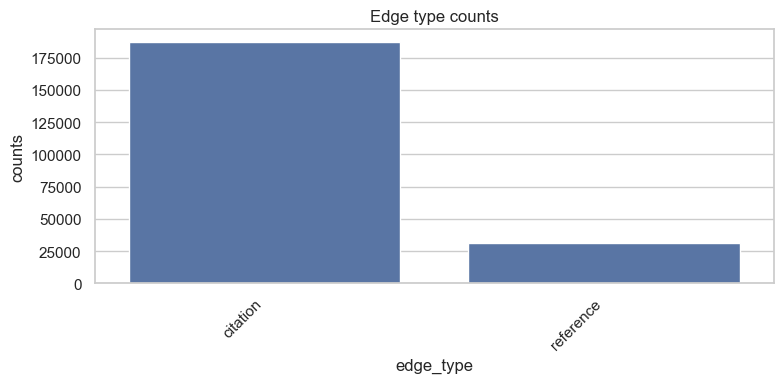

In [9]:
# Categorical counts: edge_type, hop

if not edges.empty:
    summary = edges['edge_type'].value_counts().rename_axis('edge_type').reset_index(name='counts')
    display(summary.head(10))
    plt.figure(figsize=(8,4))
    sns.barplot(data=summary.head(20), x='edge_type', y='counts')
    plt.xticks(rotation=45, ha='right')
    plt.title('Edge type counts')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'edge_type_counts.png')
    plt.show()
